# Clean unnormalized-drift audit

This notebook isolates the single-bandwidth attraction-minus-repulsion drift from DW4. It answers four questions before any further particle-system training:

1. Are the attraction and repulsion signs and relative scaling correct?
2. Is the field exactly a descent direction for empirical Gaussian-kernel MMD?
3. Does direct particle evolution follow that gradient flow and where does it fail?
4. What changes when the same local field is amortized into a one-shot neural generator?

There are no broad kernels, minimum-distance terms, collision penalties, alignment, or DW4-specific features here.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

torch.manual_seed(7)
np.random.seed(7)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})

Matplotlib is building the font cache; this may take a moment.


## 1. Define an analytically understood target and the clean field

The target is a balanced mixture of two one-dimensional Gaussians. For the Gaussian kernel $k_h(x,y)$, the implemented field is

$$v(x_i)=\frac1n\sum_j \nabla_{x_i}k_h(x_i,y_j)-\frac1m\sum_j \nabla_{x_i}k_h(x_i,x_j).$$

The self term is zero, so retaining it in the denominator makes this exactly the field associated with the biased empirical MMD used below.

In [2]:
def sample_target(count, generator=None):
    component = torch.randint(2, (count,), generator=generator)
    means = torch.where(component == 0, -2.0, 2.0)
    return means + 0.35 * torch.randn(count, generator=generator)


def target_density(x):
    normalizer = 0.35 * math.sqrt(2.0 * math.pi)
    return 0.5 * (
        torch.exp(-0.5 * ((x + 2.0) / 0.35) ** 2)
        + torch.exp(-0.5 * ((x - 2.0) / 0.35) ** 2)
    ) / normalizer


def gaussian_kernel(left, right, bandwidth):
    residual = right[None, :] - left[:, None]
    return torch.exp(-residual.square() / (2.0 * bandwidth**2))


def clean_field(generated, reference, bandwidth):
    positive_residual = reference[None, :] - generated[:, None]
    positive_kernel = torch.exp(-positive_residual.square() / (2.0 * bandwidth**2))
    attraction = (positive_kernel * positive_residual).mean(dim=1) / bandwidth**2

    negative_residual = generated[None, :] - generated[:, None]
    negative_kernel = torch.exp(-negative_residual.square() / (2.0 * bandwidth**2))
    repulsion = (negative_kernel * negative_residual).mean(dim=1) / bandwidth**2
    return attraction - repulsion, attraction, repulsion


def biased_mmd2(generated, reference, bandwidth):
    return (
        gaussian_kernel(generated, generated, bandwidth).mean()
        + gaussian_kernel(reference, reference, bandwidth).mean()
        - 2.0 * gaussian_kernel(generated, reference, bandwidth).mean()
    )


def wasserstein_1(left, right, points=2048):
    q = torch.linspace(0.0, 1.0, min(points, len(left), len(right)))
    return (torch.quantile(left, q) - torch.quantile(right, q)).abs().mean().item()

## 2. Exact sign and scaling check

For $m$ generated particles, the clean field should equal $-(m/2)\nabla_x\operatorname{MMD}^2$. This cell fails loudly if either sign or relative attraction/repulsion scaling is wrong.

In [3]:
reference_check = sample_target(31).double()
generated_check = torch.linspace(-4.0, 4.0, 17, dtype=torch.float64).requires_grad_(True)
bandwidth = 0.55
mmd_check = biased_mmd2(generated_check, reference_check, bandwidth)
autograd_gradient, = torch.autograd.grad(mmd_check, generated_check)
field_check, attraction_check, repulsion_check = clean_field(
    generated_check.detach(), reference_check, bandwidth
)
expected_field = -(len(generated_check) / 2.0) * autograd_gradient
maximum_error = (field_check - expected_field).abs().max().item()
print(f"maximum |field + (m/2) grad MMD^2| = {maximum_error:.3e}")
assert maximum_error < 1e-10
print("PASS: attraction - repulsion has the correct sign and biased-MMD scaling.")

maximum |field + (m/2) grad MMD^2| = 1.110e-16
PASS: attraction - repulsion has the correct sign and biased-MMD scaling.


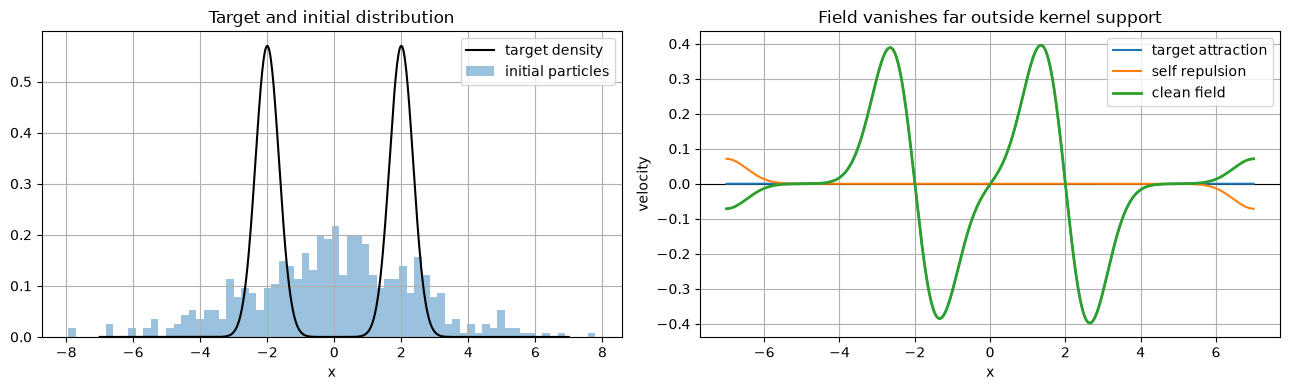

In [4]:
grid = torch.linspace(-7.0, 7.0, 700)
reference_field = sample_target(4096)
probe_generated = torch.randn(512) * 2.5
total, attraction, repulsion = clean_field(grid, reference_field, bandwidth)
_, _, probe_repulsion = clean_field(grid, probe_generated, bandwidth)
total_with_probe = attraction - probe_repulsion

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(grid, target_density(grid), color="black", label="target density")
axes[0].hist(probe_generated, bins=70, density=True, alpha=0.45, label="initial particles")
axes[0].legend()
axes[0].set(title="Target and initial distribution", xlabel="x")
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].plot(grid, attraction, label="target attraction")
axes[1].plot(grid, probe_repulsion, label="self repulsion")
axes[1].plot(grid, total_with_probe, linewidth=2, label="clean field")
axes[1].legend()
axes[1].set(title="Field vanishes far outside kernel support", xlabel="x", ylabel="velocity")
plt.tight_layout()
plt.show()

## 3. Direct particle gradient flow

This is the cleanest possible realization of the distributional gradient flow: update particles themselves, with no neural network or optimizer. If this fails, the failure belongs to the kernel flow rather than model capacity.

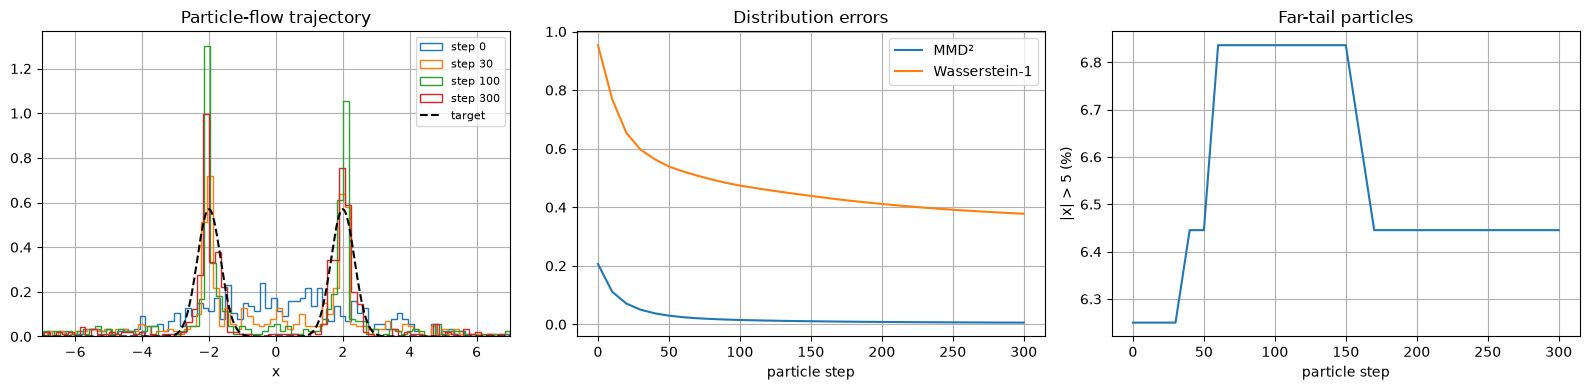

W1: 0.9534 -> 0.3778
MMD²: 0.206198 -> 0.005875
far tail: 6.25% -> 6.45%
largest recorded MMD² increase: -1.469e-04


In [5]:
flow_reference = sample_target(2048)
particles = torch.randn(512) * 2.5
initial_particles = particles.clone()
snapshots = {0: particles.clone()}
history = []
flow_steps = 300
step_size = 0.12

for step in range(flow_steps + 1):
    if step % 10 == 0:
        history.append((
            step,
            biased_mmd2(particles, flow_reference, bandwidth).item(),
            wasserstein_1(particles, flow_reference),
            (particles.abs() > 5.0).double().mean().item(),
        ))
    if step in {30, 100, 300}:
        snapshots[step] = particles.clone()
    if step < flow_steps:
        velocity, _, _ = clean_field(particles, flow_reference, bandwidth)
        particles = particles + step_size * velocity

history = np.asarray(history)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for step, values in snapshots.items():
    axes[0].hist(values, bins=90, density=True, histtype="step", label=f"step {step}")
axes[0].plot(grid, target_density(grid), color="black", linestyle="--", label="target")
axes[0].set_xlim(-7, 7)
axes[0].set(title="Particle-flow trajectory", xlabel="x")
axes[0].legend(fontsize=8)
axes[1].plot(history[:, 0], history[:, 1], label="MMD²")
axes[1].plot(history[:, 0], history[:, 2], label="Wasserstein-1")
axes[1].set(title="Distribution errors", xlabel="particle step")
axes[1].legend()
axes[2].plot(history[:, 0], 100.0 * history[:, 3])
axes[2].set(title="Far-tail particles", xlabel="particle step", ylabel="|x| > 5 (%)")
plt.tight_layout()
plt.show()
print(f"W1: {history[0, 2]:.4f} -> {history[-1, 2]:.4f}")
print(f"MMD²: {history[0, 1]:.6f} -> {history[-1, 1]:.6f}")
print(f"far tail: {100*history[0, 3]:.2f}% -> {100*history[-1, 3]:.2f}%")
maximum_mmd_increase = np.diff(history[:, 1]).max()
print(f"largest recorded MMD² increase: {maximum_mmd_increase:.3e}")
assert maximum_mmd_increase <= 1e-10

## 4. Amortize the same field into a one-shot generator

This mirrors the current DW4 training pattern: draw fresh latent noise, generate endpoints, construct a detached Euler target, and update a network. The field itself is unchanged. Any gap from direct particle flow is amortization/optimization error.

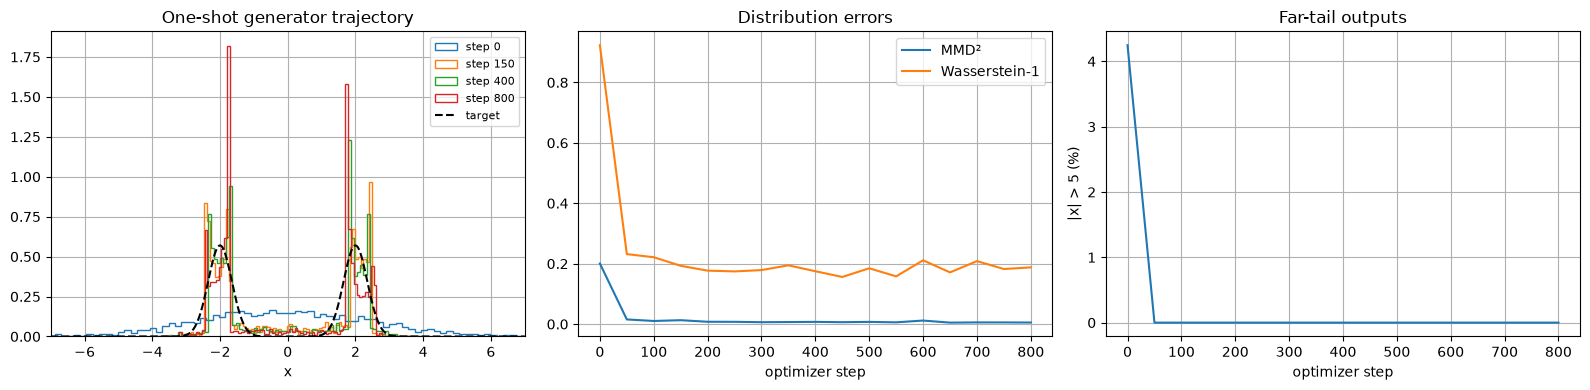

W1: 0.9234 -> 0.1878
MMD²: 0.200476 -> 0.005172
far tail: 4.25% -> 0.00%


In [6]:
class OneShotGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.SiLU(),
            nn.Linear(64, 64), nn.SiLU(),
            nn.Linear(64, 1),
        )
        with torch.no_grad():
            self.net[-1].weight.mul_(0.05)
            self.net[-1].bias.zero_()

    def forward(self, latent):
        return latent + self.net(latent[:, None]).squeeze(1)


torch.manual_seed(7)
model = OneShotGenerator()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
fixed_latent = torch.randn(2048) * 2.5
one_shot_reference = sample_target(2048)
one_shot_history = []
one_shot_snapshots = {}
training_steps = 800
eta = 0.2

for step in range(training_steps + 1):
    if step % 50 == 0:
        with torch.no_grad():
            probe = model(fixed_latent)
            one_shot_history.append((
                step,
                biased_mmd2(probe, one_shot_reference, bandwidth).item(),
                wasserstein_1(probe, one_shot_reference),
                (probe.abs() > 5.0).double().mean().item(),
            ))
            if step in {0, 150, 400, 800}:
                one_shot_snapshots[step] = probe.clone()
    if step == training_steps:
        break
    latent = torch.randn(256) * 2.5
    generated = model(latent)
    reference_batch = sample_target(512)
    velocity, _, _ = clean_field(generated.detach(), reference_batch, bandwidth)
    target = generated.detach() + eta * velocity
    loss = (generated - target).square().mean()
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

one_shot_history = np.asarray(one_shot_history)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for step, values in one_shot_snapshots.items():
    axes[0].hist(values, bins=90, density=True, histtype="step", label=f"step {step}")
axes[0].plot(grid, target_density(grid), color="black", linestyle="--", label="target")
axes[0].set_xlim(-7, 7)
axes[0].set(title="One-shot generator trajectory", xlabel="x")
axes[0].legend(fontsize=8)
axes[1].plot(one_shot_history[:, 0], one_shot_history[:, 1], label="MMD²")
axes[1].plot(one_shot_history[:, 0], one_shot_history[:, 2], label="Wasserstein-1")
axes[1].set(title="Distribution errors", xlabel="optimizer step")
axes[1].legend()
axes[2].plot(one_shot_history[:, 0], 100.0 * one_shot_history[:, 3])
axes[2].set(title="Far-tail outputs", xlabel="optimizer step", ylabel="|x| > 5 (%)")
plt.tight_layout()
plt.show()
print(f"W1: {one_shot_history[0, 2]:.4f} -> {one_shot_history[-1, 2]:.4f}")
print(f"MMD²: {one_shot_history[0, 1]:.6f} -> {one_shot_history[-1, 1]:.6f}")
print(f"far tail: {100*one_shot_history[0, 3]:.2f}% -> {100*one_shot_history[-1, 3]:.2f}%")

## 5. Interpretation checklist

Use the observed results to separate failure modes:

- **The scaling assertion passes:** the clean implementation is exactly a biased-MMD descent field; the attraction/repulsion signs are not reversed.
- **Particle MMD falls but remote particles remain:** this is kernel-support blindness. An unnormalized Gaussian KDE field approaches zero far from both distributions. It is intrinsic to this clean finite-bandwidth flow, not a DW4 bug. In the deterministic check above, MMD falls by roughly 97% while the far-tail fraction does not improve.
- **The one-shot network can behave differently from literal particle flow:** shared parameters can move remote outputs through generalization even when their local field is almost zero. In this simple 1D run it actually removes the far tail, but this is an architectural inductive bias rather than a guarantee of the clean objective. A gap in either direction is amortization/optimization behavior.
- **Both work on this toy but DW4 retains a tail:** next audit the sorted-distance representation and equivariant model capacity, without introducing data-specific kernels.

The current repository contains no preserved copy or Git history of the imported unnormalized-drift implementation. Therefore this notebook validates our mathematics and training interpretation, but cannot establish whether the missing original method intended particle iteration, a time-conditioned field, or one-shot amortization. That must be checked against the original source before claiming a faithful reproduction.

## 6. Gate before returning to DW4

Do not tune DW4 yet. First require: (1) the exact-gradient assertion passes, (2) MMD decreases monotonically for a sufficiently small particle-flow step, (3) the difference between particle flow and one-shot training is understood, and (4) the original algorithm's intended transport parameterization is recovered from its source or paper.

## 7. DW4: direct clean particle flow in sorted-distance space

This is the corresponding DW4 audit. It uses the production invariant descriptor and its clean single-bandwidth field, but evolves the generated configurations themselves. It therefore removes the EGNN, Adam, EMA, feature noise, broad kernel, and minimum-distance component from the experiment.

In [ ]:
from pathlib import Path
import sys

root = next(path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (path / "particle_systems").is_dir())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from particle_systems.drift import UnnormalizedDrift, invariant_descriptor, median_bandwidth
from particle_systems.evaluate import distribution_metrics
from particle_systems.io import load_dataset
from particle_systems.systems import center, dw4_energy, pair_distances

dw4_train, _ = load_dataset(root / "particle_systems/data/dw4.npz", "train")
dw4_test, _ = load_dataset(root / "particle_systems/data/dw4.npz", "test")
dw4_reference = dw4_train[:1024]
dw4_test = dw4_test[:10000]
dw4_base_bandwidth = median_bandwidth(dw4_train[:1024])
dw4_bandwidth = 0.5 * dw4_base_bandwidth

def descriptor_mmd2(generated, reference, bandwidth):
    generated_descriptor = invariant_descriptor(generated)
    reference_descriptor = invariant_descriptor(reference)
    def kernel(left, right):
        squared_error = (right[None, :] - left[:, None]).square().mean(dim=-1)
        return torch.exp(-squared_error / (2.0 * bandwidth**2))
    return (kernel(generated_descriptor, generated_descriptor).mean()
            + kernel(reference_descriptor, reference_descriptor).mean()
            - 2.0 * kernel(generated_descriptor, reference_descriptor).mean())

print(f"base bandwidth = {dw4_base_bandwidth:.4f}; clean audit bandwidth = {dw4_bandwidth:.4f}")

In [ ]:
torch.manual_seed(42)
dw4_particles = center(2.5 * torch.randn(512, 4, 2))
dw4_initial = dw4_particles.clone()
dw4_drift = UnnormalizedDrift(dw4_bandwidth)
dw4_snapshots = {0: dw4_particles.clone()}
dw4_history = []
dw4_steps = 1000
dw4_eta = 0.2
reference_q99 = torch.quantile(dw4_energy(dw4_test), 0.99)

for step in range(dw4_steps + 1):
    if step % 10 == 0:
        metrics = distribution_metrics(dw4_particles, dw4_test, "dw4")
        _, field_metrics = dw4_drift(
            dw4_particles, dw4_reference, dw4_particles, torch.arange(len(dw4_particles))
        )
        energy = dw4_energy(dw4_particles)
        dw4_history.append((
            step, metrics["energy_wasserstein_1"], metrics["pair_distance_wasserstein_1"],
            metrics["radius_wasserstein_1"], metrics["collision_fraction_d_lt_0_5"],
            (energy > reference_q99).double().mean().item(), field_metrics["positive_kernel_mass"].item(),
            descriptor_mmd2(dw4_particles, dw4_reference, dw4_bandwidth).item(),
        ))
    if step in {25, 100, 300, 1000}:
        dw4_snapshots[step] = dw4_particles.clone()
    if step < dw4_steps:
        field, _ = dw4_drift(
            dw4_particles, dw4_reference, dw4_particles, torch.arange(len(dw4_particles))
        )
        dw4_particles = center(dw4_particles + dw4_eta * field)

dw4_history = np.asarray(dw4_history)
print("step, energy W1, pair W1, radius W1, collision, above reference q99, positive kernel mass, descriptor MMD²")
for row in dw4_history[[0, -1]]:
    print(row)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
energy_limits = torch.quantile(dw4_energy(dw4_test), torch.tensor([0.001, 0.999])).tolist()
for step, values in dw4_snapshots.items():
    axes[0, 0].hist(dw4_energy(values), bins=100, density=True, histtype="step", label=f"step {step}")
axes[0, 0].hist(dw4_energy(dw4_test), bins=100, density=True, histtype="step", color="black", linestyle="--", label="reference")
axes[0, 0].set(xlim=energy_limits, title="Energy bulk (tail clipped for visibility)", xlabel="DW4 energy")
axes[0, 0].legend(fontsize=8)
axes[0, 1].plot(dw4_history[:, 0], dw4_history[:, 1], label="energy W1")
axes[0, 1].plot(dw4_history[:, 0], dw4_history[:, 2], label="pair-distance W1")
axes[0, 1].plot(dw4_history[:, 0], dw4_history[:, 3], label="radius W1")
axes[0, 1].set(title="Distribution errors", xlabel="particle-flow step")
axes[0, 1].legend()
axes[1, 0].plot(dw4_history[:, 0], 100 * dw4_history[:, 4], label="collisions")
axes[1, 0].plot(dw4_history[:, 0], 100 * dw4_history[:, 5], label="energy above reference q99")
axes[1, 0].set(title="Failure-mode mass", xlabel="particle-flow step", ylabel="percent")
axes[1, 0].legend()
axes[1, 1].plot(dw4_history[:, 0], dw4_history[:, 6], color="tab:blue")
axes[1, 1].set(title="Kernel support and descriptor objective", xlabel="particle-flow step", ylabel="positive kernel mass")
mmd_axis = axes[1, 1].twinx()
mmd_axis.plot(dw4_history[:, 0], dw4_history[:, 7], color="tab:orange")
mmd_axis.set_ylabel("descriptor MMD²")
plt.tight_layout()
plt.show()

print("Interpretation: if the kernel mass stays near zero for the bad particles while the bulk errors decrease, the clean field has the same support problem in DW4 itself.")

In [ ]:
_, final_mass_components = dw4_drift._field(dw4_particles, dw4_reference)
final_kernel_mass = final_mass_components["kernel_mass"]
final_energy = dw4_energy(dw4_particles)
final_collision = pair_distances(dw4_particles).min(dim=-1).values < 0.5
final_tail = final_energy > reference_q99

def group_summary(name, mask):
    values = final_kernel_mass[mask]
    print(f"{name}: n={int(mask.sum())}, median kernel mass={values.median().item():.3e}, mean={values.mean().item():.3e}")

group_summary("all samples", torch.ones_like(final_tail, dtype=torch.bool))
group_summary("energy above reference q99", final_tail)
group_summary("collision samples", final_collision)
group_summary("non-tail samples", ~final_tail)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(final_energy[~final_collision], final_kernel_mass[~final_collision], s=10, alpha=0.35, label="non-collision")
axes[0].scatter(final_energy[final_collision], final_kernel_mass[final_collision], s=16, alpha=0.8, color="tab:red", label="collision")
axes[0].axvline(reference_q99, color="black", linestyle="--", label="reference energy q99")
axes[0].set_yscale("log")
axes[0].set(title="KDE support versus physical energy", xlabel="DW4 energy", ylabel="positive kernel mass")
axes[0].legend(fontsize=8)
axes[1].hist(final_kernel_mass[~final_tail], bins=60, alpha=0.6, density=True, label="at/below reference q99")
axes[1].hist(final_kernel_mass[final_tail], bins=60, alpha=0.6, density=True, label="above reference q99")
axes[1].set(title="Support distribution", xlabel="positive kernel mass")
axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Matched IMQ-kernel test

The inverse-multiquadric (IMQ) kernel is a single generic heavy-tailed kernel: $k(r)=(1+r^2/h^2)^{-1/2}$. Unlike the Gaussian, its force decreases polynomially. This comparison uses exactly the same DW4 particles, references, bandwidth, and Euler step as Section 7.

In [ ]:
def run_dw4_particle_flow(kernel):
    particles = dw4_initial.clone()
    drift = UnnormalizedDrift(dw4_bandwidth, kernel=kernel)
    history = []
    for step in range(dw4_steps + 1):
        if step % 10 == 0:
            metrics = distribution_metrics(particles, dw4_test, "dw4")
            _, field_metrics = drift(
                particles, dw4_reference, particles, torch.arange(len(particles))
            )
            energy = dw4_energy(particles)
            history.append((
                step, metrics["energy_wasserstein_1"], metrics["pair_distance_wasserstein_1"],
                metrics["radius_wasserstein_1"], metrics["collision_fraction_d_lt_0_5"],
                (energy > reference_q99).float().mean().item(), field_metrics["positive_kernel_mass"].item(),
            ))
        if step < dw4_steps:
            field, _ = drift(particles, dw4_reference, particles, torch.arange(len(particles)))
            particles = center(particles + dw4_eta * field)
    return particles, np.asarray(history), drift

dw4_imq_particles, dw4_imq_history, dw4_imq_drift = run_dw4_particle_flow("imq")
print("IMQ start:", dw4_imq_history[0])
print("IMQ end:  ", dw4_imq_history[-1])

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for history, label in ((dw4_history, "Gaussian"), (dw4_imq_history, "IMQ")):
    axes[0].plot(history[:, 0], history[:, 1], label=label)
    axes[1].plot(history[:, 0], 100 * history[:, 4], label=f"{label}: collisions")
    axes[1].plot(history[:, 0], 100 * history[:, 5], linestyle="--", label=f"{label}: above ref q99")
    axes[2].plot(history[:, 0], history[:, 6], label=label)
axes[0].set(title="Energy Wasserstein-1", xlabel="particle-flow step")
axes[1].set(title="Tail and collision mass", xlabel="particle-flow step", ylabel="percent")
axes[2].set(title="Mean positive kernel mass", xlabel="particle-flow step")
for axis in axes:
    axis.legend(fontsize=8)
plt.tight_layout()
plt.show()

_, imq_mass_components = dw4_imq_drift._field(dw4_imq_particles, dw4_reference)
imq_mass = imq_mass_components["kernel_mass"]
imq_energy = dw4_energy(dw4_imq_particles)
imq_tail = imq_energy > reference_q99
imq_collision = pair_distances(dw4_imq_particles).min(dim=-1).values < 0.5
print(f"IMQ tail mass: {imq_tail.float().mean().item():.2%}; collision mass: {imq_collision.float().mean().item():.2%}")
print(f"IMQ median kernel mass, tail/non-tail: {imq_mass[imq_tail].median().item():.3e} / {imq_mass[~imq_tail].median().item():.3e}")